# Analyze DPL Results

In [1]:
from pathlib import Path
import pickle
import json

import pandas as pd
import numpy as np

In [2]:
from temp import (
    mis_metrics,
    plot_mis_predictions
)

In [ ]:
# Dataset configuration

# dataset = "darpa2000"
# scenario = "s1_inside"

dataset = "aitv2"
scenario = "fox"

In [ ]:
# DARPA2000
# logic_files = [
#     "darpa", 
#     "darpa_neg",
#     "darpa_one_net", 
#     "darpa_flags", 
#     "darpa_flags_neg",
#     "darpa_flags_one_net",
# ]

# AIT Log v2
logic_files = [
    "ait_neg",
]

## Load Original Flows

In [ ]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)
df['t_rel'] = df['start_time'] - df['start_time'].min()

In [5]:
phase_bounds = (
    df[df['phase'] > 0]
    .groupby('phase')['t_rel']
    .agg(['min', 'max'])
)

phase_start = phase_bounds['min'].to_dict()
phase_end   = phase_bounds['max'].to_dict()

In [6]:
phase_bounds

,min,max
phase,,
1,2.248226,205486.809459
2,302353.638809,304668.057688
3,304679.807969,304706.937194
4,304708.681596,306808.561706


## Load DPL Dataset

In [7]:
def load_dpl_dataset(logic_file, cache_file_name):
    dpl_dataset_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/cache/")
    cache_file_test = dpl_dataset_dir / cache_file_name

    cache = pickle.load(open(cache_file_test, "rb"))
    cache_df = pd.DataFrame(cache)
    cache_df.head()

    return cache_df

## Load DPL Metrics

In [ ]:
phase_map = {
    "benign": 0,
    "phase1": 1,
    "phase2": 2,
    "phase3": 3,
    "phase4": 4,
    "phase5": 5,
}

In [11]:
experiments = {}

for logic_file in logic_files:
    # --- Load metrics ---
    metrics_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/metrics")
    file_paths = list(metrics_dir.iterdir())
        
    for file_path in file_paths:
        experiment_name = f"{file_path.stem[:-16]}" # Remove "run_id"

        # Metrics
        print(f"Processing {experiment_name}...")
        data = np.load(file_path, allow_pickle=True)
        print(experiment_name)
        experiments[experiment_name] = {
            "confusion_matrix": data["confusion_matrix"],
            "classes": data["classes"].tolist(),
            "metrics": data["metrics"].item(),
        }

Processing ait_neg_scratch_50data_w10...
ait_neg_scratch_50data_w10
Processing ait_neg_scratch_25data_w10...
ait_neg_scratch_25data_w10


## Analyze Results

Experiment: ait_neg_scratch_50data_w10
Experiment: ait_neg_scratch_25data_w10


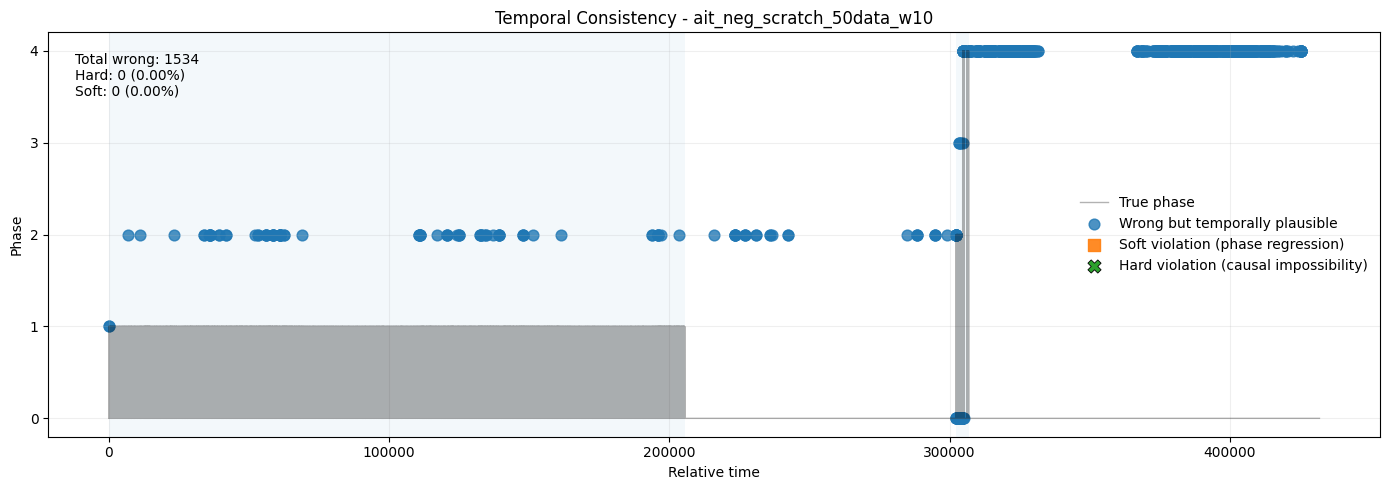

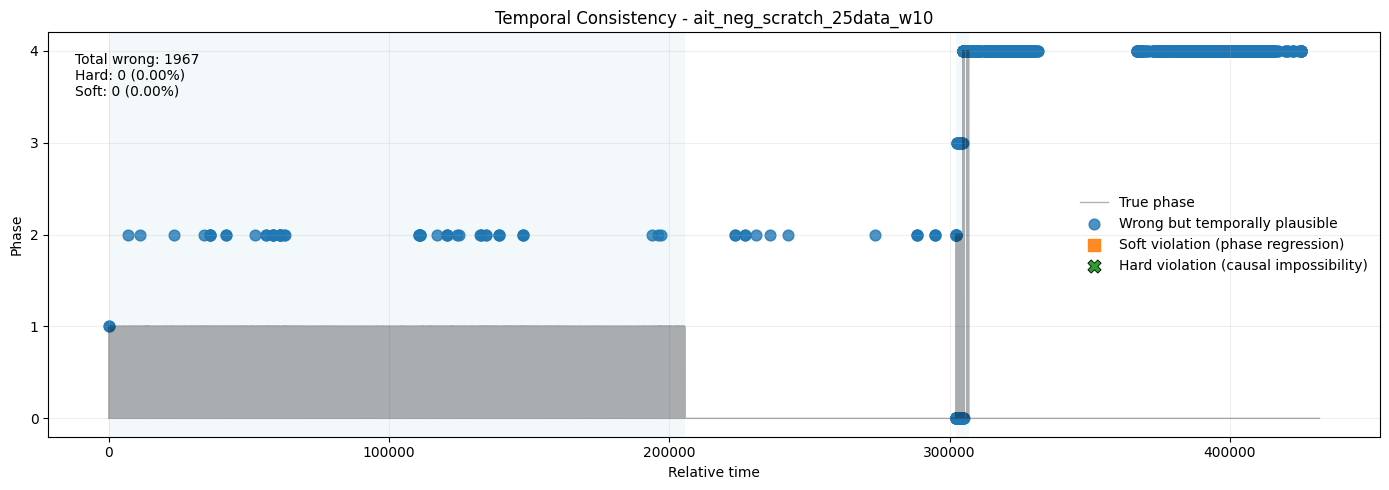

In [13]:
results = []

for logic_file in logic_files:

    # --- Load errors ---
    err_folder = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/errors/")
    file_paths = list(err_folder.iterdir())

    for file_path in file_paths:

        experiment_name = file_path.stem[:-16] # Remove "run_id"
        parts = experiment_name.split("_")
        
        cache_file_name = f"{logic_file}_{parts[-2]}_{parts[-1]}_test.pkl"
        cache_df = load_dpl_dataset(logic_file, cache_file_name)

        with open(file_path, "r") as f:
            errors = json.load(f)
        
        dpl_to_orig = dict(zip(cache_df['dpl_index'], cache_df['orig_index']))

        original_indices = []
        mis_y_preds = []
        mis_y_trues = []

        for error in errors:
            dpl_index = error['index']
            original_indices.append(dpl_to_orig[dpl_index])

            y_pred = error['predicted']
            y_true = error['actual']
            mis_y_preds.append(phase_map[y_pred])
            mis_y_trues.append(phase_map[y_true])

        mis_df = df.loc[original_indices].copy()
        mis_df['y_pred'] = mis_y_preds
        mis_df['y_true'] = mis_y_trues

        # --- Compute violation categories ---
        wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)

        total_wrong = len(wrong)
        hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
        soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

        # --- Collect everything ---
        print(f"Experiment: {experiment_name}")
        metrics = experiments[experiment_name]['metrics']
        
        results.append({
            "model": f"{experiment_name}",
            "accuracy": metrics["accuracy"],
            "precision" : metrics["macro_precision"],
            "recall" : metrics["macro_recall"], 
            "f1": metrics["macro_f1"],
            "FPR": metrics["false_alarm_rate"],
            "Detection Rate": metrics["detection_rate"],
            "total_wrong": total_wrong,
            "hard_violations": len(hard),
            "soft_violations": len(soft),
            "hard_rate": hard_rate,
            "soft_rate": soft_rate,
        })

        # Create plots
        out_dir = Path(f"../reports/deepproblog/{logic_file}/temp")
        out_dir.mkdir(parents=True, exist_ok=True)

        plot_mis_predictions(
            df, 
            phase_bounds, 
            plausible, 
            soft, 
            hard, 
            total_wrong, 
            soft_rate, 
            hard_rate, 
            experiment_name, 
            out_dir, 
            show_plot=False
        )




## Metrics for All Models

In [14]:
results_df = pd.DataFrame(results)

results_df

,model,accuracy,precision,recall,f1,FPR,Detection Rate,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate
0,ait_neg_scratch_50data_w10,0.991862,0.739856,0.963440,0.767496,0.007387,0.987642,1534,0,0,0.0,0.0
1,ait_neg_scratch_25data_w10,0.989564,0.675021,0.961575,0.709419,0.009006,0.981533,1967,0,0,0.0,0.0


In [15]:
results_df["temporal_score"] = (
    results_df["f1"]
    - 0.5 * results_df["hard_rate"]
    - 0.2 * results_df["soft_rate"]
)

In [16]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    f"../reports/deepproblog/temporal_consistency_summary.csv",
    index=False
)

In [17]:
results_df_sorted_f1.head(10)

,model,accuracy,precision,recall,f1,FPR,Detection Rate,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
0,ait_neg_scratch_50data_w10,0.991862,0.739856,0.963440,0.767496,0.007387,0.987642,1534,0,0,0.0,0.0,0.767496
1,ait_neg_scratch_25data_w10,0.989564,0.675021,0.961575,0.709419,0.009006,0.981533,1967,0,0,0.0,0.0,0.709419


In [18]:
results_df_sorted_temp = results_df.sort_values("temporal_score", ascending=False)

results_df_sorted_temp.head()

,model,accuracy,precision,recall,f1,FPR,Detection Rate,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
0,ait_neg_scratch_50data_w10,0.991862,0.739856,0.963440,0.767496,0.007387,0.987642,1534,0,0,0.0,0.0,0.767496
1,ait_neg_scratch_25data_w10,0.989564,0.675021,0.961575,0.709419,0.009006,0.981533,1967,0,0,0.0,0.0,0.709419
